# Ejercicio 3

1. Obtenga versiones mejoradas de diferentes imágenes mediante el filtrado por máscara difusa. Implemente el cálculo como

$$
g(x,y) = f(x,y) - PB(f(x,y))
$$

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
import helpers

firewatch = cv2.imread("firewatch.png", cv2.IMREAD_GRAYSCALE)
huang = cv2.imread("huang1.jpg", cv2.IMREAD_GRAYSCALE)
hubble = cv2.imread("hubble.tif", cv2.IMREAD_GRAYSCALE)

# funcion de actualizacion
def aplicarFiltro(size, sigma, A):
    A = 1 if A==1.0 else A  # para safar la cara de errores de precision (A=1.0 es 1.00...algo, o sea 1.0>1)
    # filtrar
    img_f = helpers.altaPotencia(img=firewatch, kernelSize=(size, size), sigma=sigma, A=A)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # img original
    ax[0].imshow(firewatch, cmap="gray")
    ax[0].set_title("Original")
    ax[0].axis("off")

    # img filtrada
    ax[1].imshow(img_f, cmap="gray")
    ax[1].set_title(f"Filtrada")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

interact(
    aplicarFiltro,
    size=IntSlider(
        value=3,
        min=1,
        max=31,
        step=2, # valores impares
        description="Tamaño de kernel"
    ),
    sigma=FloatSlider(
        value=1,
        min=0.1,
        max=5,
        step=0.1,
        description="sigma"
    ),
    A=FloatSlider(
        value=1,
        min=1,
        max=5,
        step=0.1,
        description="A"
    )
);

interactive(children=(IntSlider(value=3, description='Tamaño de kernel', max=31, min=1, step=2), FloatSlider(v…

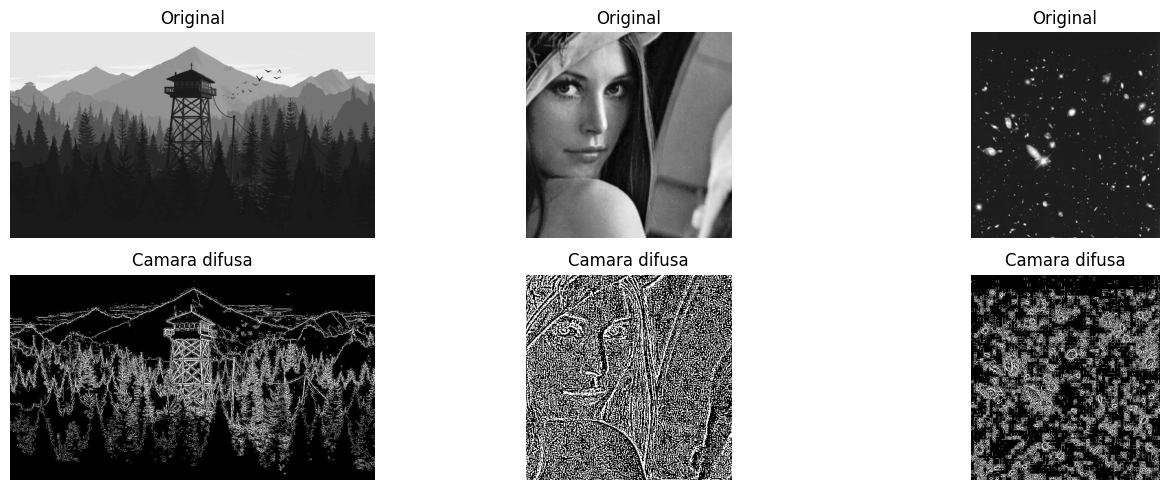

In [2]:
# Alta potencia con A=1 es equivalente a mascara difusa
As = [1, 1.5, 2.5, 3.5]

fig, ax = plt.subplots(2, 3, figsize=(14, 5))

# original
ax[0][0].imshow(firewatch, cmap="gray")
ax[0][0].set_title("Original")
ax[0][0].axis("off")
ax[0][1].imshow(huang, cmap="gray")
ax[0][1].set_title("Original")
ax[0][1].axis("off")
ax[0][2].imshow(hubble, cmap="gray")
ax[0][2].set_title("Original")
ax[0][2].axis("off")

# alta potencia
ax[1][0].imshow(helpers.altaPotencia(img=firewatch, A=1), cmap="gray")
ax[1][0].set_title(f"Camara difusa")
ax[1][0].axis("off")
ax[1][1].imshow(helpers.altaPotencia(img=huang, A=1), cmap="gray")
ax[1][1].set_title(f"Camara difusa")
ax[1][1].axis("off")
ax[1][2].imshow(helpers.altaPotencia(img=hubble, A=1), cmap="gray")
ax[1][2].set_title(f"Camara difusa")
ax[1][2].axis("off")

plt.tight_layout()
plt.show();

2. Una forma de enfatizar las altas frecuencias sin perder los detalles de bajas frecuencias es el filtrado de alta potencia. Implemente este procesamiento como la operación aritmética:

$$
g(x,y) = Af(x,y) - PB(f(x,y)), \text{ con A }\geq 1
$$

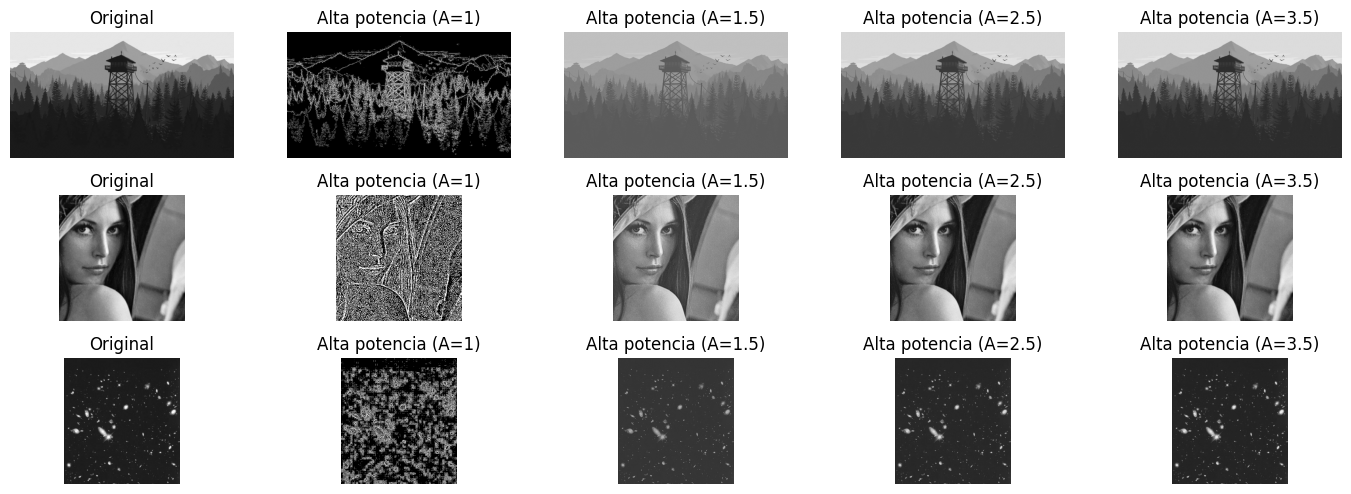

In [3]:
# Alta potencia con A=1 es equivalente a mascara difusa
As = [1, 1.5, 2.5, 3.5]

fig, ax = plt.subplots(3, 5, figsize=(14, 5))

# original
ax[0][0].imshow(firewatch, cmap="gray")
ax[0][0].set_title("Original")
ax[0][0].axis("off")
ax[1][0].imshow(huang, cmap="gray")
ax[1][0].set_title("Original")
ax[1][0].axis("off")
ax[2][0].imshow(hubble, cmap="gray")
ax[2][0].set_title("Original")
ax[2][0].axis("off")

# alta potencia
for i,A in enumerate(As):
    ax[0][i+1].imshow(helpers.altaPotencia(img=firewatch, A=A), cmap="gray")
    ax[0][i+1].set_title(f"Alta potencia (A={A})")
    ax[0][i+1].axis("off")
    ax[1][i+1].imshow(helpers.altaPotencia(img=huang, A=A), cmap="gray")
    ax[1][i+1].set_title(f"Alta potencia (A={A})")
    ax[1][i+1].axis("off")
    ax[2][i+1].imshow(helpers.altaPotencia(img=hubble, A=A), cmap="gray")
    ax[2][i+1].set_title(f"Alta potencia (A={A})")
    ax[2][i+1].axis("off")

plt.tight_layout()
plt.show();